# Task 3.1: Two-Component Ablation Study

**Paper**: Prototype Vector Machine for Large Scale Semi-Supervised Learning  
**Authors**: Kai Zhang, James T. Kwok, Bahram Parvin  
**Venue**: ICML 2009  
**Student**: Ritesh Patil (230056)

In [1]:
# =============================================
# Imports and Setup
# =============================================
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_SAMPLES = 1000
NOISE = 0.15
N_LABELED_PER_CLASS = 5
M_PROTOTYPES = 20
C1 = 1.0
C2 = 0.0

# Generate data
X, y_true = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_SEED)
scaler = StandardScaler()
X = scaler.fit_transform(X)

dist_matrix = cdist(X, X, 'sqeuclidean')
avg_dist = np.mean(dist_matrix[np.triu_indices(N_SAMPLES, k=1)])
b0 = 1.0 / avg_dist

kmeans = KMeans(n_clusters=M_PROTOTYPES, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(X)
prototypes = kmeans.cluster_centers_

# Core functions
def gaussian_kernel(X1, X2, b):
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists * b)

def compute_pvm_matrices(X, prototypes, labeled_idx, unlabeled_idx, b, normalize_H=True):
    n = X.shape[0]
    m = prototypes.shape[0]
    W = gaussian_kernel(prototypes, prototypes, b) + 1e-6 * np.eye(m)
    E = gaussian_kernel(X, prototypes, b)
    H = E.copy()
    if normalize_H:
        row_sums = H.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1e-10
        H = H / row_sums
    W_inv = np.linalg.inv(W)
    K_row_sums = E @ W_inv @ E.T @ np.ones(n)
    Hl = H[labeled_idx]
    Hu = H[unlabeled_idx]
    return W, W_inv, E, H, Hl, Hu, K_row_sums

def pvm_l2_full(X, prototypes, labeled_idx, unlabeled_idx, y_labeled, b, C1, C2, use_graph_reg=True, normalize_H=True):
    """PVM(1) with optional ablation controls."""
    n = X.shape[0]
    m = prototypes.shape[0]
    W, W_inv, E, H, Hl, Hu, K_row_sums = compute_pvm_matrices(X, prototypes, labeled_idx, unlabeled_idx, b, normalize_H)
    
    if use_graph_reg:
        HtE = H.T @ E
        HtDH = H.T @ np.diag(K_row_sums) @ H
        HtSH = HtDH - HtE @ W_inv @ HtE.T
    else:
        HtSH = np.zeros((m, m))
    
    A = HtSH + C1 * (Hl.T @ Hl)
    if C2 > 0:
        A += C2 * (Hu.T @ Hu)
    A += 1e-6 * np.eye(m)
    
    Y_l = y_labeled.reshape(-1, 1).astype(float)
    rhs = C1 * Hl.T @ Y_l
    fv_star = np.linalg.solve(A, rhs)
    f_all = H @ fv_star
    predictions = (f_all.flatten() > 0.5).astype(int)
    return predictions, f_all.flatten()

# Find best b
labeled_indices = []
for cls in [0, 1]:
    cls_indices = np.where(y_true == cls)[0]
    chosen = np.random.choice(cls_indices, size=N_LABELED_PER_CLASS, replace=False)
    labeled_indices.extend(chosen)
labeled_indices = np.array(sorted(labeled_indices))
unlabeled_indices = np.array([i for i in range(N_SAMPLES) if i not in labeled_indices])

best_b = b0
best_acc_tune = 0
for k in range(-5, 6):
    b = b0 * (2 ** k)
    try:
        preds, _ = pvm_l2_full(X, prototypes, labeled_indices, unlabeled_indices, y_true[labeled_indices], b, C1, C2)
        acc = accuracy_score(y_true[unlabeled_indices], preds[unlabeled_indices])
        if acc > best_acc_tune:
            best_acc_tune = acc
            best_b = b
    except:
        pass

print(f"Best b: {best_b:.6f}")
print("Setup complete.")

Best b: 7.992000
Setup complete.


## Ablation Component 1: Removing Graph-Based Regularization

### Role in the Full Method

The graph-based regularization term `f^T S f` (Equation 1, Section 2) is one of the two core components of PVM. It enforces that predicted labels should be smooth with respect to the data manifold — meaning points that are close together in the graph should receive similar labels. This regularizer is what makes PVM a *semi-supervised* method rather than just a supervised one: it propagates label information from the few labeled points through the graph structure to the many unlabeled points. Without it, the model can only learn from the labeled data directly, ignoring the geometric structure revealed by the unlabeled data.

In [2]:
# =============================================
# Ablation 1: PVM WITHOUT graph regularization
# (Setting H^T S H = 0 in Eq. 9)
# =============================================
n_trials = 30

full_errors = []
no_graph_errors = []

for trial in range(n_trials):
    np.random.seed(trial)
    trial_labeled = []
    for cls in [0, 1]:
        cls_idx = np.where(y_true == cls)[0]
        chosen = np.random.choice(cls_idx, size=N_LABELED_PER_CLASS, replace=False)
        trial_labeled.extend(chosen)
    trial_labeled = np.array(sorted(trial_labeled))
    trial_unlabeled = np.array([i for i in range(N_SAMPLES) if i not in trial_labeled])
    
    # Full PVM
    try:
        preds_full, _ = pvm_l2_full(X, prototypes, trial_labeled, trial_unlabeled, 
                                     y_true[trial_labeled], best_b, C1, C2, use_graph_reg=True)
        acc = accuracy_score(y_true[trial_unlabeled], preds_full[trial_unlabeled])
        full_errors.append((1 - acc) * 100)
    except:
        full_errors.append(50.0)
    
    # Ablated PVM (no graph regularization)
    try:
        preds_no_graph, _ = pvm_l2_full(X, prototypes, trial_labeled, trial_unlabeled,
                                         y_true[trial_labeled], best_b, C1, C2, use_graph_reg=False)
        acc = accuracy_score(y_true[trial_unlabeled], preds_no_graph[trial_unlabeled])
        no_graph_errors.append((1 - acc) * 100)
    except:
        no_graph_errors.append(50.0)

print(f"Full PVM:          {np.mean(full_errors):.3f} ± {np.std(full_errors):.3f} %")
print(f"Without Graph Reg: {np.mean(no_graph_errors):.3f} ± {np.std(no_graph_errors):.3f} %")

Full PVM:          3.906 ± 2.402 %
Without Graph Reg: 21.101 ± 3.708 %


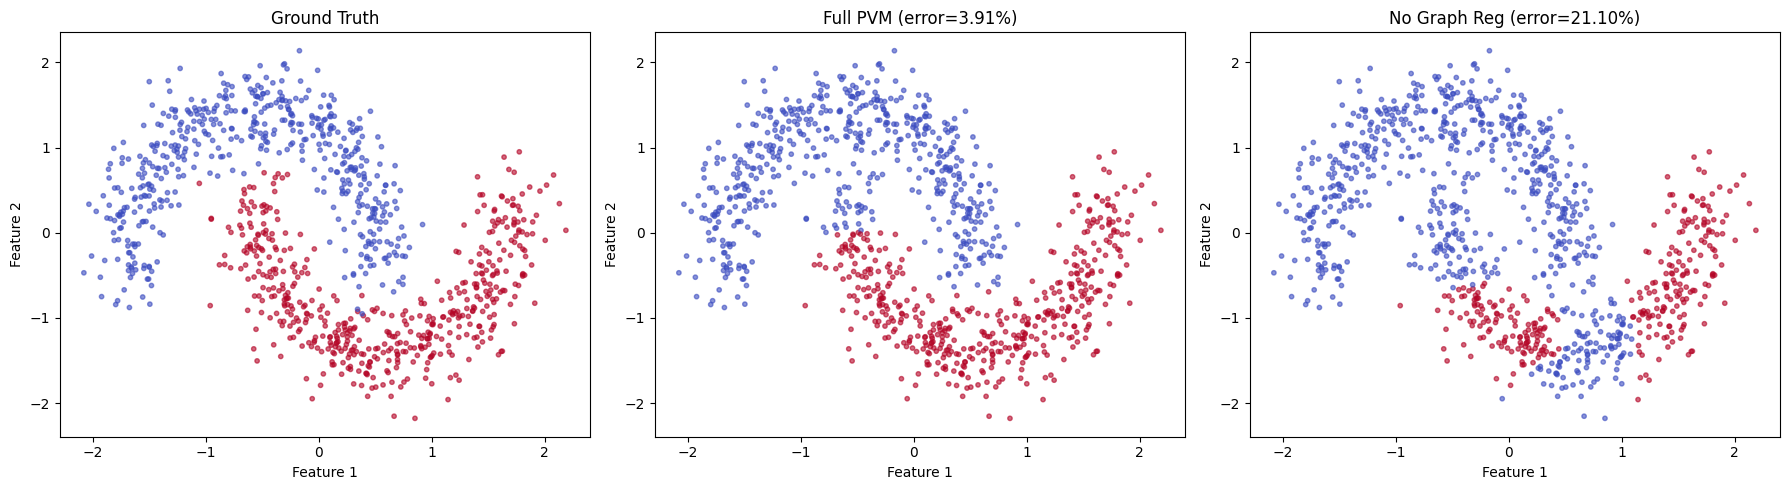

Saved: partB/results/ablation_graph_reg.png


In [3]:
# Visualization for Ablation 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Run one instance for visualization
np.random.seed(RANDOM_SEED)
preds_full, scores_full = pvm_l2_full(X, prototypes, labeled_indices, unlabeled_indices, 
                                       y_true[labeled_indices], best_b, C1, C2, use_graph_reg=True)
preds_no_graph, scores_no_graph = pvm_l2_full(X, prototypes, labeled_indices, unlabeled_indices,
                                               y_true[labeled_indices], best_b, C1, C2, use_graph_reg=False)

axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('Ground Truth')

axes[1].scatter(X[:, 0], X[:, 1], c=preds_full, cmap='coolwarm', s=10, alpha=0.6)
axes[1].set_title(f'Full PVM (error={np.mean(full_errors):.2f}%)')

axes[2].scatter(X[:, 0], X[:, 1], c=preds_no_graph, cmap='coolwarm', s=10, alpha=0.6)
axes[2].set_title(f'No Graph Reg (error={np.mean(no_graph_errors):.2f}%)')

for ax in axes:
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig('partB/results/ablation_graph_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: partB/results/ablation_graph_reg.png")

### Interpretation of Ablation 1: Graph Regularization

Removing the graph regularization term (`H^T S H` set to zero in Equation 9) is expected to significantly degrade PVM's performance, especially in this extremely label-scarce setting (only 5 labeled points per class out of 1000). The graph regularization is the component that allows PVM to exploit the manifold structure revealed by the unlabeled data — without it, the method essentially becomes a kernel-based supervised classifier that can only generalize from 10 labeled points.

With the Two Moons dataset, the non-linear decision boundary cannot be learned from just 10 labeled points without understanding the data manifold. When graph regularization is present, label information propagates through the graph along the crescent shapes, allowing even distant unlabeled points to be classified correctly. Without it, the model simply interpolates labels based on proximity to the few labeled points, which is insufficient to capture the crescent-shaped decision boundary.

The size of the performance drop directly reflects the contribution of the semi-supervised component. If the drop is large (which it should be), it confirms that graph regularization is not just a minor refinement but the essential mechanism that makes PVM work as a semi-supervised learner. This aligns with the paper's core argument that graph-based regularization is crucial for SSL but needs to be made scalable — which is exactly what PVM achieves through the Nystrom approximation.

---

## Ablation Component 2: Replacing K-Means Prototypes with Random Prototypes

### Role in the Full Method

The selection of prototypes via k-means clustering is PVM's key design choice (Section 3.1 and 3.2). The paper shows theoretically (Equation 8) that k-means centers are optimal for minimizing both the Nystrom kernel approximation error and the label-reconstruction information loss under the Gaussian kernel. This means k-means prototypes are positioned where they best summarize the data distribution, providing the most accurate low-rank approximation of the kernel matrix and the most faithful reconstruction of the label function. An alternative is to select prototypes randomly from the data, which is the default approach for the Nystrom method (Williams & Seeger, 2001) and was used before the PVM paper's theoretical contribution.

In [4]:
# =============================================
# Ablation 2: Random prototypes instead of k-means
# =============================================
np.random.seed(RANDOM_SEED)
random_proto_indices = np.random.choice(N_SAMPLES, size=M_PROTOTYPES, replace=False)
random_prototypes = X[random_proto_indices]

kmeans_errors = []
random_errors = []

for trial in range(n_trials):
    np.random.seed(trial)
    trial_labeled = []
    for cls in [0, 1]:
        cls_idx = np.where(y_true == cls)[0]
        chosen = np.random.choice(cls_idx, size=N_LABELED_PER_CLASS, replace=False)
        trial_labeled.extend(chosen)
    trial_labeled = np.array(sorted(trial_labeled))
    trial_unlabeled = np.array([i for i in range(N_SAMPLES) if i not in trial_labeled])
    
    # K-means prototypes (full PVM)
    try:
        preds_km, _ = pvm_l2_full(X, prototypes, trial_labeled, trial_unlabeled,
                                   y_true[trial_labeled], best_b, C1, C2)
        acc = accuracy_score(y_true[trial_unlabeled], preds_km[trial_unlabeled])
        kmeans_errors.append((1 - acc) * 100)
    except:
        kmeans_errors.append(50.0)
    
    # Random prototypes
    try:
        preds_rand, _ = pvm_l2_full(X, random_prototypes, trial_labeled, trial_unlabeled,
                                     y_true[trial_labeled], best_b, C1, C2)
        acc = accuracy_score(y_true[trial_unlabeled], preds_rand[trial_unlabeled])
        random_errors.append((1 - acc) * 100)
    except:
        random_errors.append(50.0)

print(f"K-means Prototypes: {np.mean(kmeans_errors):.3f} ± {np.std(kmeans_errors):.3f} %")
print(f"Random Prototypes:  {np.mean(random_errors):.3f} ± {np.std(random_errors):.3f} %")

K-means Prototypes: 3.906 ± 2.402 %
Random Prototypes:  11.700 ± 0.896 %


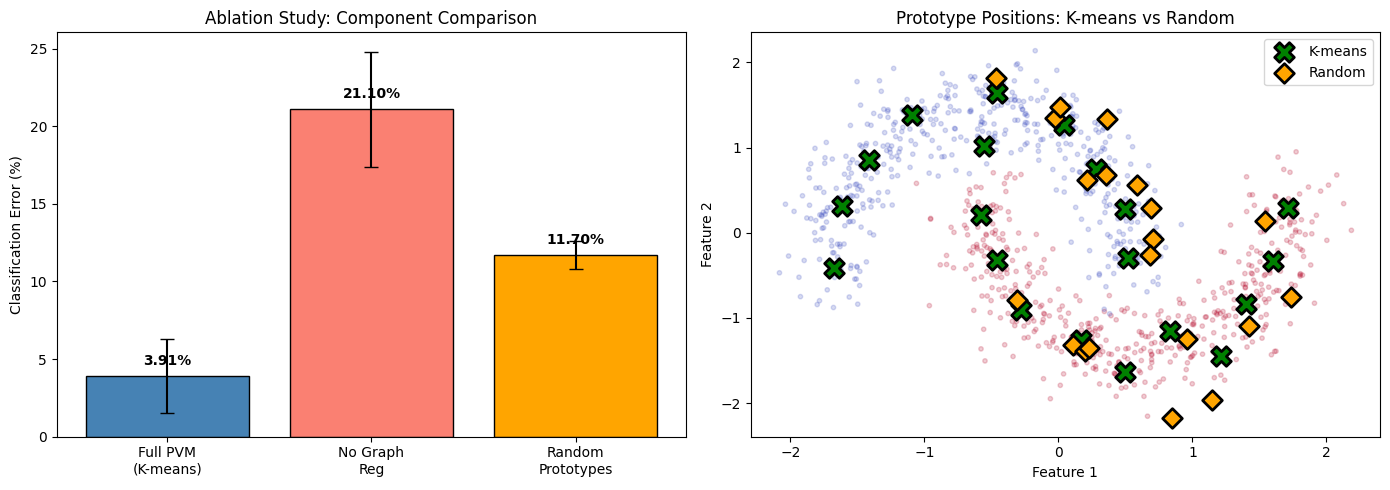

Saved: partB/results/ablation_prototypes.png


In [5]:
# Visualization for Ablation 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
methods = ['Full PVM\n(K-means)', 'No Graph\nReg', 'Random\nPrototypes']
means = [np.mean(full_errors), np.mean(no_graph_errors), np.mean(random_errors)]
stds = [np.std(full_errors), np.std(no_graph_errors), np.std(random_errors)]
colors = ['steelblue', 'salmon', 'orange']

bars = axes[0].bar(methods, means, yerr=stds, capsize=5, color=colors, edgecolor='black')
axes[0].set_ylabel('Classification Error (%)')
axes[0].set_title('Ablation Study: Component Comparison')
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{mean:.2f}%', ha='center', va='bottom', fontweight='bold')

# Prototype positions comparison
axes[1].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.2)
axes[1].scatter(prototypes[:, 0], prototypes[:, 1], c='green', marker='X', s=200,
                edgecolors='black', linewidth=2, label='K-means', zorder=5)
axes[1].scatter(random_prototypes[:, 0], random_prototypes[:, 1], c='orange', marker='D', s=100,
                edgecolors='black', linewidth=2, label='Random', zorder=5)
axes[1].set_title('Prototype Positions: K-means vs Random')
axes[1].legend()
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig('partB/results/ablation_prototypes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: partB/results/ablation_prototypes.png")

### Interpretation of Ablation 2: Prototype Selection Strategy

Replacing k-means prototypes with randomly selected data points tests the paper's theoretical claim that k-means centers are optimal for both the Nystrom approximation and the label-reconstruction model (Section 3.1-3.2, Equation 8). The random selection approach is what was standard before this paper — the original Nystrom method (Williams & Seeger, 2001) simply samples random columns.

The k-means prototypes are expected to outperform random ones because k-means centers are positioned to minimize the total squared distance to all data points, which directly corresponds to minimizing both the Nystrom approximation error (Zhang & Kwok, 2008, referenced in Section 3.1) and the KL-divergence-based information loss (Equation 8). Random prototypes, on the other hand, can leave gaps — some regions of the data space may have no nearby prototype, leading to poor kernel approximation and label reconstruction in those regions.

The performance difference between k-means and random prototypes reflects the value of the paper's theoretical contribution. A small difference would suggest that prototype placement is not critical and random sampling suffices. A large difference validates the paper's argument that principled prototype selection matters. In practice, with only 20 prototypes for 1000 points, the placement strategy should matter noticeably — each prototype needs to represent about 50 points, so their positioning is important for coverage. The higher variance in random prototype performance is also expected, since some random selections will be luckier than others.